In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/INM/ML_Feb26/housingData.csv')
data

,house_area,house_price,bedrooms,lift
0,1262.881245,38.156437,3bhk,NaN
1,1143.840962,35.415229,2bhk,0.0
2,1362.809667,42.734290,3bhk,0.0
3,1215.430502,38.252915,2bhk,NaN
4,1078.882497,33.886475,1bhk,0.0
...,...,...,...,...
995,1019.644332,32.719330,1bhk,NaN
996,1153.063719,34.981912,NaN,NaN
997,1255.712846,38.081385,3bhk,NaN
998,1240.645962,39.179379,3bhk,NaN


In [ ]:
## Perform EDA on this Data -> A detailed visual and non-visual analysis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   house_area   998 non-null    float64
 1   house_price  996 non-null    float64
 2   bedrooms     888 non-null    object 
 3   lift         665 non-null    float64
dtypes: float64(3), object(1)
memory usage: 31.4+ KB


In [ ]:
df=data.copy()

# Data Preprocessing

## Null Values Handling

In [ ]:
# Column wise % of null values
df.isna().sum()/len(df)

,0
house_area,0.002
house_price,0.004
bedrooms,0.112
lift,0.335


In [ ]:
## Observations
# 1. Very less null values in house_area and house_price (ie 0.2% and 0.4%)

In [ ]:
## Show rows where house_area / house_price are null
df[(df['house_area'].isnull()) | (df['house_price'].isnull())]

## Total 6 rows out of 1000 having null house_area or null house_price
## As very few rows in these columns have null values, we can do data prunning ie drop these 6 rows

,house_area,house_price,bedrooms,lift
186,1098.497620,NaN,NaN,NaN
383,1108.383595,NaN,1bhk,1.0
419,NaN,38.483874,2bhk,NaN
445,1266.283530,NaN,3bhk,NaN
810,1069.700230,NaN,1bhk,1.0
859,NaN,41.140350,3bhk,1.0


In [ ]:
df.dropna(subset=['house_area','house_price'],inplace=True)

In [ ]:
# Column wise % of null values
df.isna().sum()/len(df)

,0
house_area,0.000000
house_price,0.000000
bedrooms,0.111670
lift,0.334004


In [ ]:
## Observation
# 2. Too many null values in column 'lift'
# We don't have any good assumption to data impute this column as well as null values are too many, hence we'll drop this column

In [ ]:
df.drop(['lift'],axis=1,inplace=True)
df

,house_area,house_price,bedrooms
0,1262.881245,38.156437,3bhk
1,1143.840962,35.415229,2bhk
2,1362.809667,42.734290,3bhk
3,1215.430502,38.252915,2bhk
4,1078.882497,33.886475,1bhk
...,...,...,...
995,1019.644332,32.719330,1bhk
996,1153.063719,34.981912,NaN
997,1255.712846,38.081385,3bhk
998,1240.645962,39.179379,3bhk


In [ ]:
# Observation
# bedrooms column has 11% null values and bedrooms can have a strong relationship with house_area
# This relationship can help us in replacing null values with some valid values

<Axes: xlabel='bedrooms', ylabel='house_area'>

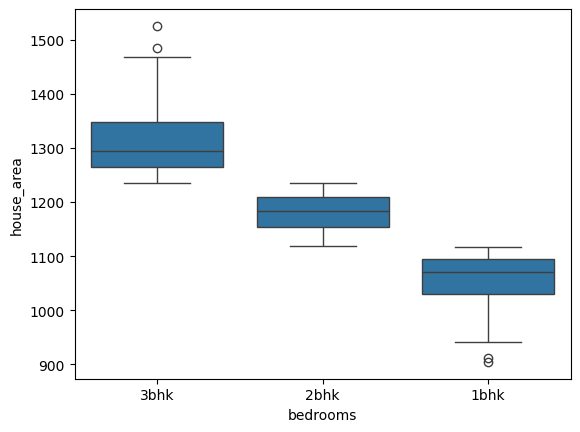

In [ ]:
## Find relationship between house_area and bedrooms columns
# Bivariate Analysis
# house_area -> continuous
# bedrooms -> categorical/discrete

sns.boxplot(data=df,x='bedrooms',y='house_area')

In [ ]:
## Observations - from bivariate analysis
# 1. There is clear relationship between house_area and bedrooms
# 2. We can say from visualization that approximately
# area < 1100 -> 1bhk
# 1100 < area < 1250 -> 2bhk
# area > 1250 -> 3bhk

# Using this relationship, we can to data imputation for null values of bedrooms bcz this looks a very good assumption

In [ ]:
## Data Imputation for bedrooms column
# 1. The missing values are not too many ie only 11%
# 2. We've found a very good assumption ie using relationship between house_area and bedrooms

In [ ]:
## Find rows with bedrooms null and house_area < 1100

row_indexes=df.loc[(df.bedrooms.isnull()) & (df.house_area<1100)].index
row_indexes

Index([ 46, 124, 188, 196, 218, 322, 457, 467, 484, 543, 552, 617, 658, 737,
       773, 828, 836, 890, 993],
      dtype='int64')

In [ ]:
df.loc[row_indexes,'bedrooms']=1

In [ ]:
df.loc[row_indexes]

,house_area,house_price,bedrooms
46,986.217155,30.306515,1
124,1056.704118,32.411124,1
188,1098.823535,34.484706,1
196,951.237651,30.027130,1
218,1052.025487,34.020765,1
322,1045.056931,32.181708,1
457,1068.178549,32.725356,1
467,1056.066106,32.641983,1
484,1075.975072,32.669252,1
543,1088.561881,33.506856,1


In [ ]:
## Find rows with bedrooms null and 1100 <= house_area < 1250

row_indexes=df.loc[(df.bedrooms.isnull()) & (df.house_area>=1100) & (df.house_area<1250)].index
row_indexes

df.loc[row_indexes,'bedrooms']=2
df.loc[row_indexes]

,house_area,house_price,bedrooms
6,1201.155608,37.184668,2
15,1184.647009,35.909410,2
22,1238.824756,40.504743,2
74,1157.415036,35.242451,2
90,1164.900088,35.437003,2
...,...,...,...
971,1129.899503,35.916985,2
972,1248.220737,39.096622,2
975,1160.262432,35.427873,2
986,1115.932302,34.337969,2


In [ ]:
## Find rows with bedrooms null and house_area >= 1250

row_indexes=df.loc[(df.bedrooms.isnull()) & (df.house_area>=1250)].index
row_indexes

df.loc[row_indexes,'bedrooms']=3
df.loc[row_indexes]

,house_area,house_price,bedrooms
68,1256.945302,38.058359,3
185,1259.721069,38.901632,3
221,1397.246932,43.387408,3
230,1456.596984,46.557910,3
255,1377.278593,43.688358,3
256,1368.477523,42.884326,3
306,1293.472571,41.064177,3
308,1289.418886,40.332567,3
370,1336.777481,43.013324,3
429,1351.053802,42.231614,3


In [ ]:
df.isnull().sum()

,0
house_area,0
house_price,0
bedrooms,0


## Outlier Handling

<Axes: xlabel='house_area', ylabel='Density'>

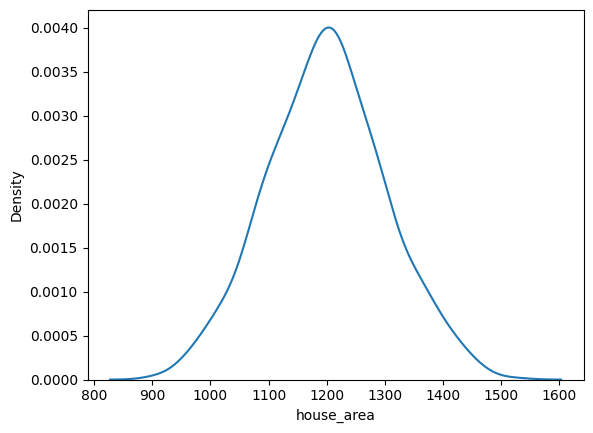

In [ ]:
sns.kdeplot(df['house_area'])

<Axes: xlabel='house_price', ylabel='Density'>

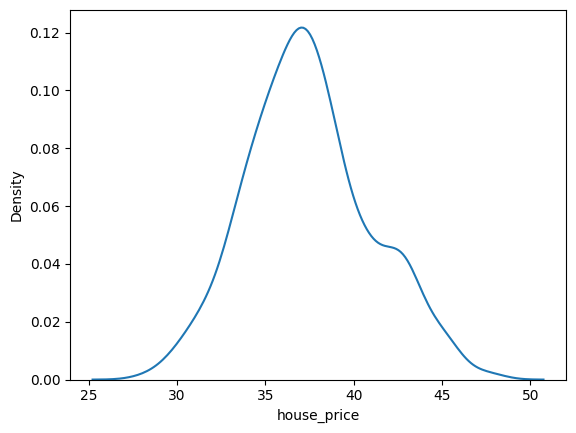

In [ ]:
sns.kdeplot(df['house_price'])

<Axes: ylabel='house_area'>

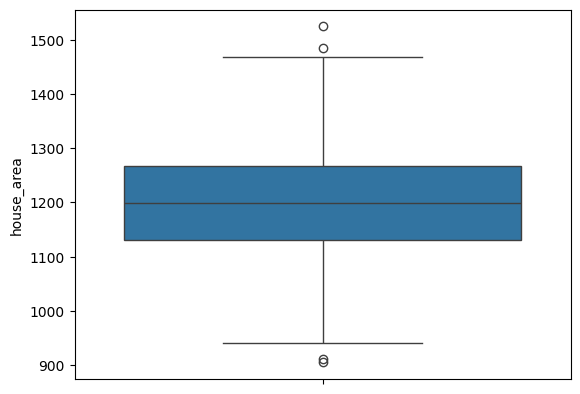

In [ ]:
sns.boxplot(df['house_area'])

<Axes: ylabel='house_price'>

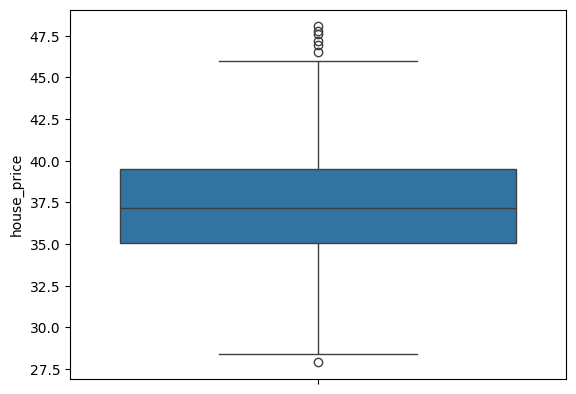

In [ ]:
sns.boxplot(df['house_price'])

In [ ]:
## Observations
# 1. Few outliers are visible in house_area and house_price using boxplot
# 2. We can approximately count the number of outliers using upper and lower bounds

In [ ]:
q3=df['house_area'].quantile(0.75)
q1=df['house_area'].quantile(0.25)
iqr=q3-q1

area_ub= q3+1.5*iqr
area_lb= q1-1.5*iqr

In [ ]:
area_ub,area_lb

(np.float64(1474.347899404294), np.float64(923.3493987322132))

In [ ]:
area_outliers = df[(df.house_area<area_lb) | (df.house_area>area_ub)]
area_outliers

,house_area,house_price,bedrooms
277,1525.378160,48.071345,3bhk
894,1484.524069,47.795722,3bhk
939,904.610767,28.378323,1bhk
976,911.688500,27.890655,1bhk


In [ ]:
q3=df['house_price'].quantile(0.75)
q1=df['house_price'].quantile(0.25)
iqr=q3-q1

price_ub= q3+1.5*iqr
price_lb= q1-1.5*iqr

print(price_ub,price_lb)


price_outliers = df[(df.house_price<price_lb) | (df.house_price>price_ub)]
price_outliers

46.22345134108595 28.35632082118205


,house_area,house_price,bedrooms
144,1463.424539,47.202736,3bhk
200,1468.436961,47.623109,3bhk
230,1456.596984,46.557910,3
277,1525.378160,48.071345,3bhk
700,1423.417393,46.932522,3bhk
894,1484.524069,47.795722,3bhk
976,911.688500,27.890655,1bhk


In [ ]:
## As number of outliers in very less and data allows us to drop the extreme values, lets drop these outliers

In [ ]:
outlier_indexes = list(area_outliers.index)+list(price_outliers.index)
outlier_indexes

[277, 894, 939, 976, 144, 200, 230, 277, 700, 894, 976]

In [ ]:
df.drop(outlier_indexes,inplace=True)
df

,house_area,house_price,bedrooms
0,1262.881245,38.156437,3bhk
1,1143.840962,35.415229,2bhk
2,1362.809667,42.734290,3bhk
3,1215.430502,38.252915,2bhk
4,1078.882497,33.886475,1bhk
...,...,...,...
995,1019.644332,32.719330,1bhk
996,1153.063719,34.981912,2
997,1255.712846,38.081385,3bhk
998,1240.645962,39.179379,3bhk


# Data Transformation

In [ ]:
# We've seen a small right skewness in house_price, we can reduce it using log-transform

df['log_price']=np.log(df['house_price'])
df

,house_area,house_price,bedrooms,log_price
0,1262.881245,38.156437,3bhk,3.641694
1,1143.840962,35.415229,2bhk,3.567142
2,1362.809667,42.734290,3bhk,3.755002
3,1215.430502,38.252915,2bhk,3.644220
4,1078.882497,33.886475,1bhk,3.523016
...,...,...,...,...
995,1019.644332,32.719330,1bhk,3.487966
996,1153.063719,34.981912,2,3.554831
997,1255.712846,38.081385,3bhk,3.639726
998,1240.645962,39.179379,3bhk,3.668151


<Axes: xlabel='log_price', ylabel='Density'>

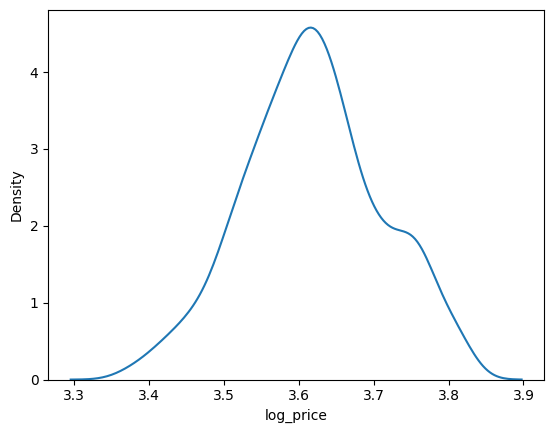

In [ ]:
sns.kdeplot(df['log_price'])

<Axes: xlabel='house_price', ylabel='Density'>

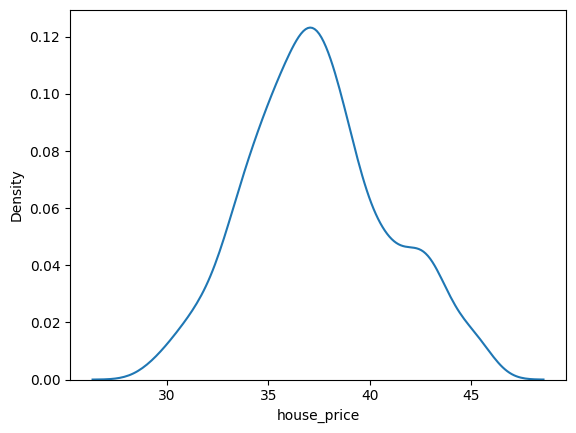

In [ ]:
sns.kdeplot(df['house_price'])

In [ ]:
## not much change in symmetry of kde plot even after log-transform
## But skewness is definetely reduced

In [ ]:
df['house_price'].skew()

np.float64(0.22905409142130984)

In [ ]:
df['log_price'].skew()

np.float64(0.00022464412331624437)

In [ ]:
df['house_area'].skew()

np.float64(0.01793811850397759)

## Feature Scaling

In [ ]:
df

,house_area,house_price,bedrooms,log_price
0,1262.881245,38.156437,3bhk,3.641694
1,1143.840962,35.415229,2bhk,3.567142
2,1362.809667,42.734290,3bhk,3.755002
3,1215.430502,38.252915,2bhk,3.644220
4,1078.882497,33.886475,1bhk,3.523016
...,...,...,...,...
995,1019.644332,32.719330,1bhk,3.487966
996,1153.063719,34.981912,2,3.554831
997,1255.712846,38.081385,3bhk,3.639726
998,1240.645962,39.179379,3bhk,3.668151


In [ ]:
## Lets formar bedrooms column to make it discrete
df['bedrooms'].unique()

array(['3bhk', '2bhk', '1bhk', 2, 1, 3], dtype=object)

In [ ]:
df['bedrooms'].replace({'3bhk':3,'2bhk':2,'1bhk':1},inplace=True)

/tmp/ipython-input-499/219024492.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].replace({'3bhk':3,'2bhk':2,'1bhk':1},inplace=True)
/tmp/ipython-input-499/219024492.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['bedrooms'].replace({'3bhk':3,'2bhk':2,'1bhk':1},inplace=True

In [ ]:
df['bedrooms'].unique()

array([3, 2, 1])

## Min-Max Scaling

In [ ]:
def min_max_scaling(data):
  _max=data.max()
  _min=data.min()
  scaled_data = (data-_min)/(_max-_min)
  return scaled_data

In [ ]:
df['scaled_bedrooms']=min_max_scaling(df['bedrooms'])
df

,house_area,house_price,bedrooms,log_price,scaled_bedrooms
0,1262.881245,38.156437,3,3.641694,1.0
1,1143.840962,35.415229,2,3.567142,0.5
2,1362.809667,42.734290,3,3.755002,1.0
3,1215.430502,38.252915,2,3.644220,0.5
4,1078.882497,33.886475,1,3.523016,0.0
...,...,...,...,...,...
995,1019.644332,32.719330,1,3.487966,0.0
996,1153.063719,34.981912,2,3.554831,0.5
997,1255.712846,38.081385,3,3.639726,1.0
998,1240.645962,39.179379,3,3.668151,1.0


In [ ]:
df['scaled_area']=min_max_scaling(df['house_area'])

df['scaled_price']=min_max_scaling(df['house_price'])

df

,house_area,house_price,bedrooms,log_price,scaled_bedrooms,scaled_area,scaled_price
0,1262.881245,38.156437,3,3.641694,1.0,0.620458,0.541395
1,1143.840962,35.415229,2,3.567142,0.5,0.391141,0.380629
2,1362.809667,42.734290,3,3.755002,1.0,0.812958,0.809877
3,1215.430502,38.252915,2,3.644220,0.5,0.529049,0.547053
4,1078.882497,33.886475,1,3.523016,0.0,0.266006,0.290970
...,...,...,...,...,...,...,...
995,1019.644332,32.719330,1,3.487966,0.0,0.151891,0.222520
996,1153.063719,34.981912,2,3.554831,0.5,0.408907,0.355215
997,1255.712846,38.081385,3,3.639726,1.0,0.606648,0.536993
998,1240.645962,39.179379,3,3.668151,1.0,0.577624,0.601388
